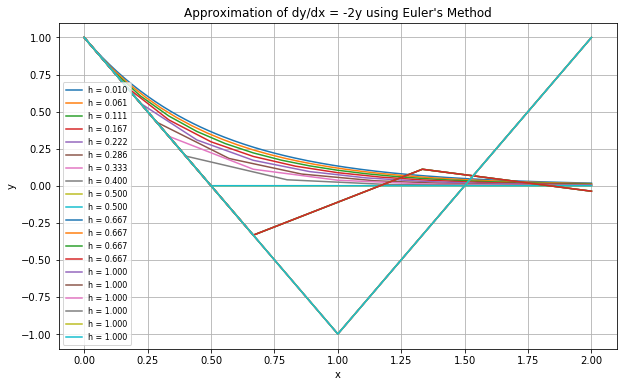

Run 1 with h = 0.010
Error (current run vs first run) for each point:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Total accumulated error: 0.000000
------------------------------------------------------------
Run 2 with h = 0.061
Error (current run vs first run) for each point:
[0.         0.         0.0004     0.001192   0.00236816 0.0039208
 0.00584238 0.00584821 0.00606146 0.00662196 0.00752276 0.00875706
 0.01031819 0.01032

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 2

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# store all runs
all_x = []
all_y = []
all_h = []

plt.figure(figsize=(10, 6))

# loop through step sizes from .01 to 1 in steps of .05
# range does not work with decimals, so np.arange is the move here
for h in np.arange(0.01, 1.01, 0.05):

    num_steps = int((x_end - x_start) / h)

    # make h fit the interval exactly so x ends right at 2
    h = (x_end - x_start) / num_steps

    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # save this run
    all_x.append(x_values)
    all_y.append(y_values)
    all_h.append(h)

    # plot each step-size run
    plt.plot(x_values, y_values, label=f"h = {h:.3f}")

# plot settings
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

# use the first run as the reference
first_x = all_x[0]
first_y = all_y[0]

# print error(current run vs first run) for each point
# and total accumulated error for each run
for run in range(len(all_y)):
    current_x = all_x[run]
    current_y = all_y[run]
    current_h = all_h[run]

    # interpolate current run onto first run's x-grid
    # so i can compare point by point even though h changes
    current_y_interp = np.interp(first_x, current_x, current_y)

    point_error = np.abs(current_y_interp - first_y)
    total_error = np.sum(point_error)

    print(f"Run {run + 1} with h = {current_h:.3f}")
    print("Error (current run vs first run) for each point:")
    print(point_error)
    print(f"Total accumulated error: {total_error:.6f}")
    print("-" * 60)

As the step size increases, the total error increases, confirming that Euler’s method becomes less accurate for larger step sizes.